# Try it yourself — the picket-fence longwave discovery

This notebook reproduces every figure and headline number in the companion post, straight from the regenerated artifacts in `_artifacts/`. Run it top to bottom in the `climt` conda environment. Each section mirrors a beat of the post: symptom → k-distribution → culprit → dead-ends → fix → payoff.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO = os.path.abspath(os.path.join('..', '..', '..'))
sys.path.insert(0, os.path.join(REPO, 'scripts', 'experiments'))
from tropopause import find_tropopause

ARTIF = '_artifacts'

def load_rce(name):
    """Final-state columns from an rce_moist --save .npz: {label: {field: array}}."""
    d = np.load(os.path.join(ARTIF, name))
    cols = sorted({k.split('__')[0] for k in d.files})
    return {c: {k.split('__')[1]: d[k] for k in d.files if k.startswith(c + '__')}
            for c in cols}

try:
    from climt import RRTMGLongwave  # noqa: F401
    RRTMG_AVAILABLE = True
except Exception as exc:  # pragma: no cover - Pyodide has no Fortran RRTMG
    RRTMG_AVAILABLE = False
    print('RRTMG unavailable (expected under Pyodide):', exc)
print('RRTMG_AVAILABLE =', RRTMG_AVAILABLE)

RRTMG_AVAILABLE = True


## 1. The symptom

The shipped-*before* 4-band Earth-LW table, run to moist radiative-convective equilibrium against RRTMG, runs away: a much warmer surface, runaway humidity, and a tropopause nowhere near RRTMG's.

In [2]:
before = load_rce('rce_moist_before.npz')
rr = next(l for l in before if l.startswith('RRTMG'))
pf = next(l for l in before if l.startswith('PF'))

dT    = float(before[pf]['T_sfc']) - float(before[rr]['T_sfc'])
tp_pf = find_tropopause(before[pf]['T'], before[pf]['p_hpa'])['p_curvature']
tp_rr = find_tropopause(before[rr]['T'], before[rr]['p_hpa'])['p_curvature']
print(f'surface warming  PF - RRTMG : {dT:+.2f} K')
print(f'q_sfc  PF {float(before[pf]["q"][0])*1e3:.2f} g/kg   vs RRTMG {float(before[rr]["q"][0])*1e3:.2f} g/kg')
print(f'tropopause (theta-curvature)  PF {tp_pf:.0f} hPa   vs RRTMG {tp_rr:.0f} hPa')

# Self-check: the 4-band default really does run away.
assert dT > 8.0, dT
assert tp_pf < 100.0, tp_pf   # convection driven absurdly deep vs RRTMG

surface warming  PF - RRTMG : +11.91 K
q_sfc  PF 6.48 g/kg   vs RRTMG 2.02 g/kg
tropopause (theta-curvature)  PF 23 hPa   vs RRTMG 238 hPa


## 2. The k-distribution, and how it fails

A correlated-k band replaces the messy absorption spectrum with its *sorted* values — a smooth `k(g)`. That is exact for one band of one population. It breaks when a band **lumps two populations** (a transparent window + opaque lines): the sorted curve grows a low-`g` shelf and a high-`g` cliff, and one shared set of g-points / Planck weight can't represent both. The regenerated figure shows exactly that for the 800–1800 cm⁻¹ window band.

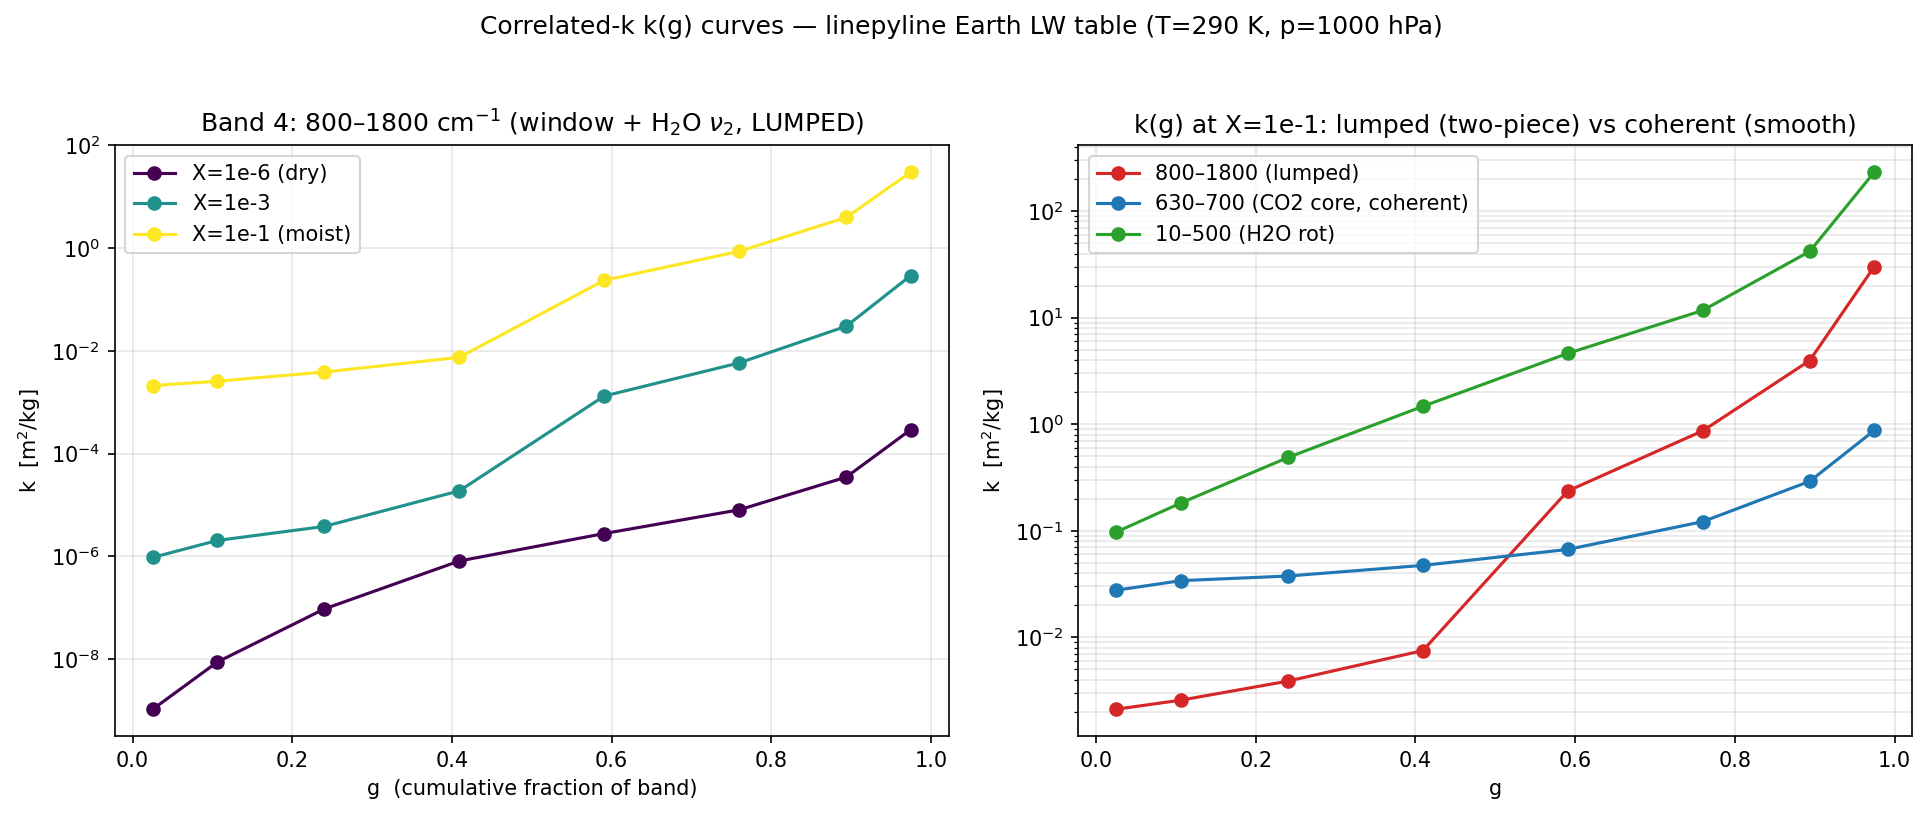

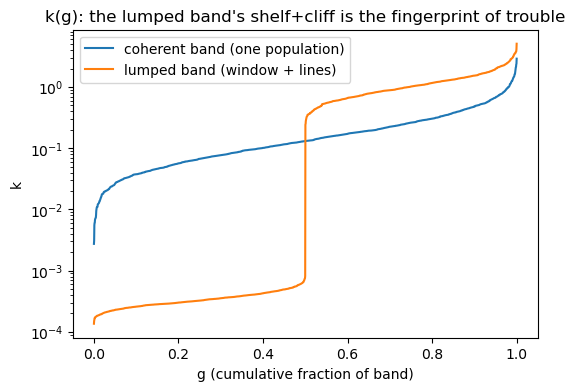

In [3]:
display(Image(os.path.join(ARTIF, 'kg_window_band.png')))

# Pure-Python toy (runs live, even under Pyodide): a k-distribution is just the
# SORTED absorption coefficients of a band. Build a 'coherent' band (one
# population) and a 'lumped' band (transparent window + opaque lines).
rng = np.random.default_rng(0)
g = np.linspace(0, 1, 2000)
coherent = np.sort(rng.lognormal(-2.0, 1.0, 2000))
lumped = np.sort(np.concatenate([rng.lognormal(-8.0, 0.3, 1000),   # window: tiny k
                                 rng.lognormal( 0.0, 0.5, 1000)]))  # lines: large k
plt.figure(figsize=(6, 4))
plt.semilogy(g, coherent, label='coherent band (one population)')
plt.semilogy(g, lumped,   label='lumped band (window + lines)')
plt.xlabel('g (cumulative fraction of band)'); plt.ylabel('k')
plt.title('k(g): the lumped band\'s shelf+cliff is the fingerprint of trouble')
plt.legend(); plt.show()

## 3. Isolating the culprit

Is the warm bias bad line data, or the scheme? Line-by-line truth (linepyline at the PF diffusivity angle) matches RRTMG; PF over-traps. So it's the **correlated-k scheme**, not the physics input.

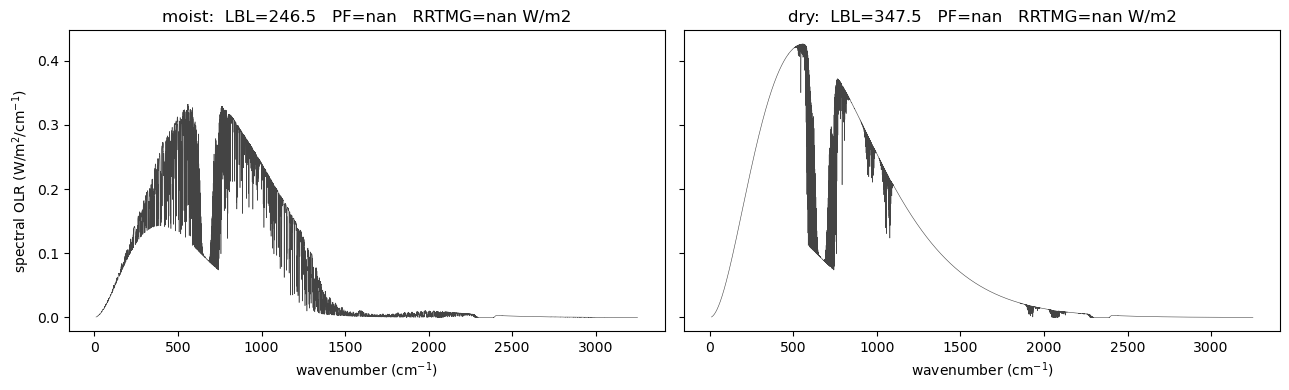

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, kind in zip(axes, ('moist', 'dry')):
    d = np.load(os.path.join(ARTIF, f'lbl_olr_spec_{kind}_co2_400ppm.npz'))
    ax.plot(d['nu'], d['olr_spec'], lw=0.4, color='#444')
    ax.set_title(f"{kind}:  LBL={float(d['total']):.1f}   "
                 f"PF={float(d['olr_pf']):.1f}   RRTMG={float(d['olr_rrtmg']):.1f} W/m2")
    ax.set_xlabel('wavenumber (cm$^{-1}$)')
axes[0].set_ylabel('spectral OLR (W/m$^2$/cm$^{-1}$)')
plt.tight_layout(); plt.show()
# Lower OLR = more trapping. PF's scalar OLR sits below the line-by-line total.

## 4. The dead-ends (and why resolution doesn't help)

The tempting fixes don't work, and that's the lesson:

- **More g-points (8 → 16 → 32):** the over-trapping barely moves. It is not a quadrature-resolution problem.
- **Finer vertical resolution:** same — no help.
- **Wing-boost hacks:** rejected.

When adding resolution doesn't move the error, you are fighting a *structural* assumption (the correlated-k spectral-correlation floor), not a numerical one. The real levers turn out to be the **H₂O continuum** (decouple it) and the **band structure** (split the lumped window band).

## 5. The fix, and the payoff

The 14-band table with a decoupled, log-X-interpolated H₂O continuum co-locates PF with RRTMG and tames the surface warming from ~+12 K to ~+2 K.

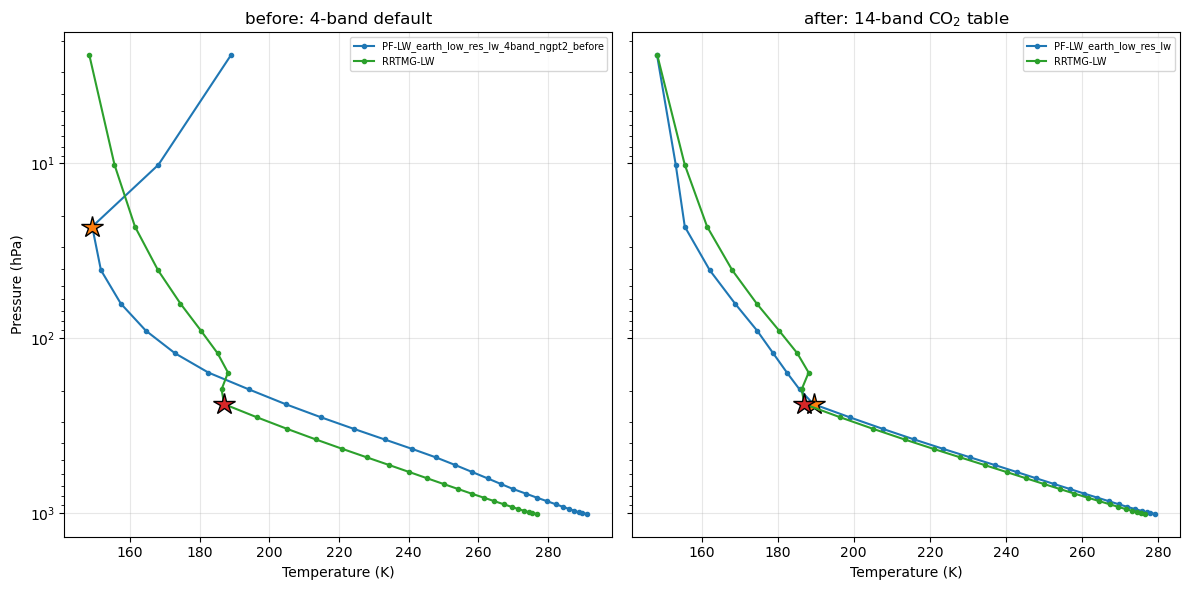

surface warming PF-RRTMG:  before +11.9 K  ->  after +2.0 K
after tropopause  PF 238 hPa  vs RRTMG 238 hPa  (co-located)


In [5]:
after = load_rce('rce_moist_after.npz')
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for ax, cols, title in ((axes[0], before, 'before: 4-band default'),
                        (axes[1], after,  'after: 14-band CO$_2$ table')):
    for label, s in cols.items():
        ax.plot(s['T'], s['p_hpa'], '-o', ms=3, label=label)
        tp = find_tropopause(s['T'], s['p_hpa'])['p_curvature']
        ax.plot(np.interp(tp, s['p_hpa'][::-1], s['T'][::-1]), tp, '*', ms=16, mec='k')
    ax.set_yscale('log'); ax.grid(alpha=0.3)
    ax.set_title(title); ax.set_xlabel('Temperature (K)'); ax.legend(fontsize=7)
axes[0].invert_yaxis()            # invert ONCE: the panels share the y-axis
axes[0].set_ylabel('Pressure (hPa)')
plt.tight_layout(); plt.show()

rr2 = next(l for l in after if l.startswith('RRTMG'))
pf2 = next(l for l in after if l.startswith('PF'))
dT_after = float(after[pf2]['T_sfc']) - float(after[rr2]['T_sfc'])
tp_pf2 = find_tropopause(after[pf2]['T'], after[pf2]['p_hpa'])['p_curvature']
tp_rr2 = find_tropopause(after[rr2]['T'], after[rr2]['p_hpa'])['p_curvature']
print(f'surface warming PF-RRTMG:  before {dT:+.1f} K  ->  after {dT_after:+.1f} K')
print(f'after tropopause  PF {tp_pf2:.0f} hPa  vs RRTMG {tp_rr2:.0f} hPa  (co-located)')
assert dT_after < 3.0, dT_after

### Which diagnostic do you trust?

A subtlety worth carrying away: a *fixed-profile* single-column LBL−PF comparison reads about +11 W/m² for **both** the prototype and the shipped table — yet the self-adjusting RCE column above converges to only ~2 K. The fixed-profile metric **over-states** the error a column that can adjust its own humidity and lapse rate actually incurs. Trust the diagnostic that matches the question you're asking.

## 6. Two more things this bought us

**Fast vs faithful.** Making the table faithful made the Python optical-depth / Planck assembly the bottleneck. Compiling the two hot loops with `@njit(parallel=True)` made the faithful 14-band scheme *faster* than RRTMG, bit-for-bit. **The free knob.** The same table is CO₂-adjustable 10–10000 ppm via one runtime axis, log-k interpolated — interpolating between nodes is fidelity-free (see `scripts/experiments/eval_co2_interp_accuracy.py`).

In [6]:
t = np.load(os.path.join(ARTIF, 'throughput.npz'))
rr_us, pf_us = float(t['rrtmg_us_per_col']), float(t['pf_us_per_col'])
print(f'throughput @ NCOL={int(t["ncol"])}:  '
      f'RRTMG {rr_us:.1f} us/col   PF {pf_us:.1f} us/col   '
      f'(PF/RRTMG = {pf_us/rr_us:.2f}x)')
# The faithful 14-band PF scheme is faster than RRTMG.
assert pf_us < rr_us, (pf_us, rr_us)

throughput @ NCOL=100:  RRTMG 65.3 us/col   PF 56.6 us/col   (PF/RRTMG = 0.87x)


## Pyodide / live-cells map

For a future in-browser (JupyterLite) port, this notebook already separates cleanly:

- **Pure-Python-live** (run under Pyodide as-is): the setup imports, the k(g) toy in §2, and the analysis/plotting of the pre-baked arrays.
- **Needs pre-baked `_artifacts/*.npz`** (their producers — RRTMG Fortran and the linepyline line-by-line code — don't run under Pyodide): the symptom (§1), the line-by-line overlay (§3), the before/after RCE (§5), and the throughput scalars (§6). The live `RRTMGLongwave` import is guarded by `RRTMG_AVAILABLE` so the notebook degrades gracefully.

That boundary is the concrete hand-off to the website spec's deferred live-cells follow-up.